В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [112]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import confusion_matrix, roc_curve, auc, root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

--- TRAIN ---
AUROC: 0.9027878246333991


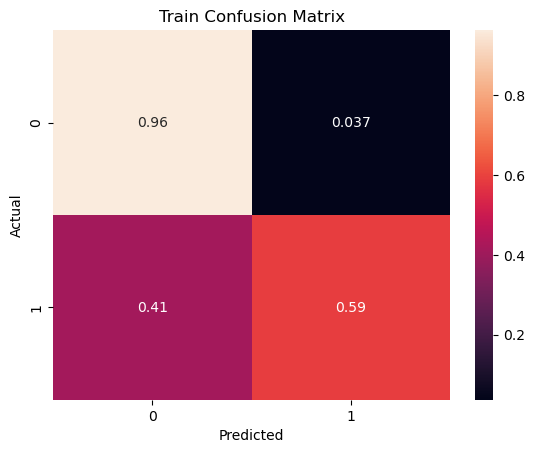

--- VALIDATION ---
AUROC: 0.8807668564373413


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


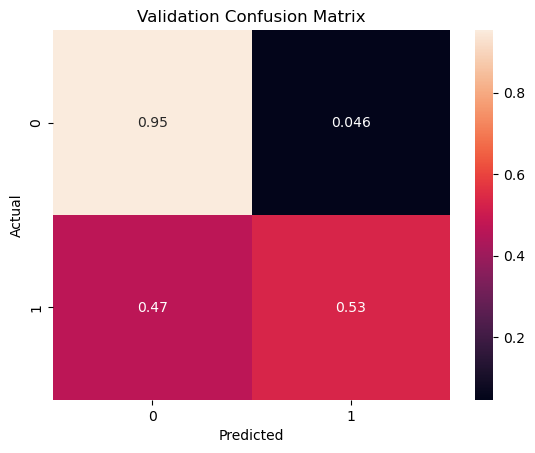

['churn_pipeline.joblib']

In [113]:
# Read train set from a file
raw_df = pd.read_csv('train.csv')

# Split data into train and validation
train_df, val_df = train_test_split(raw_df,
                                    test_size=0.2,
                                    random_state=91,
                                    stratify=raw_df.Exited)

# Select input and target subsets
input_cols = train_df.columns[1:-1]
target_col = "Exited"
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

# Select numeric and categorical columns
numeric_cols = train_inputs.select_dtypes("number").columns.to_list()
categorical_cols = train_inputs.select_dtypes("object").columns.to_list()

# Create a pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])
model_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression())
])

# Fit the pipeline
model_pipeline.fit(train_inputs, train_target)


# Create function to predict probabilities and classes + show some metrics
def predict_and_show_metrics(df_name, inputs, target):
    print(f"--- {df_name.upper()} ---")
    probs = model_pipeline.predict_proba(inputs)
    preds = model_pipeline.predict(inputs)

    fpr, tpr, thresholds = roc_curve(target, probs[:, 1])
    auc_roc = auc(fpr, tpr)

    print('AUROC:', auc_roc)

    cf_norm = confusion_matrix(target, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf_norm, annot=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{df_name} Confusion Matrix')
    plt.show()

    return {'probs': probs[:, 1], 'preds': preds}


# Make predictions and show metrics for train and val
train_results = predict_and_show_metrics('Train', train_inputs, train_target)
val_results = predict_and_show_metrics('Validation', val_inputs, val_target)

# Write model into a file
joblib.dump(model_pipeline, 'churn_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

--- TRAIN ---
AUROC: 0.9381813760344834


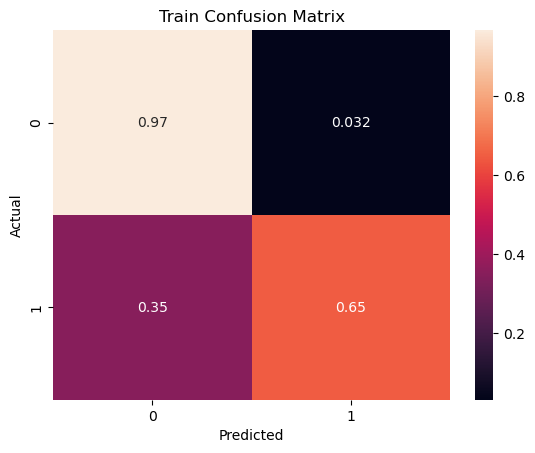

--- VALIDATION ---
AUROC: 0.9182927498456686


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


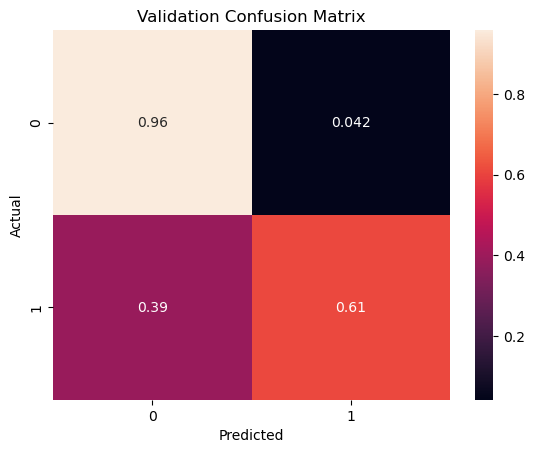

['churn_pipeline.joblib']

In [114]:
# Read train set from a file
raw_df = pd.read_csv('train.csv')

# Split data into train and validation
train_df, val_df = train_test_split(raw_df,
                                    test_size=0.2,
                                    random_state=91,
                                    stratify=raw_df.Exited)

# Select input and target subsets
input_cols = train_df.columns[1:-1]
target_col = "Exited"
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

# Select numeric and categorical columns
numeric_cols = train_inputs.select_dtypes("number").columns.to_list()
categorical_cols = train_inputs.select_dtypes("object").columns.to_list()

# Create a pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial', PolynomialFeatures())
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])
model_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression())
])

# Fit the pipeline
model_pipeline.fit(train_inputs, train_target)


# Create function to predict probabilities and classes + show some metrics
def predict_and_show_metrics(df_name, inputs, target):
    print(f"--- {df_name.upper()} ---")
    probs = model_pipeline.predict_proba(inputs)
    preds = model_pipeline.predict(inputs)

    fpr, tpr, thresholds = roc_curve(target, probs[:, 1])
    auc_roc = auc(fpr, tpr)

    print('AUROC:', auc_roc)

    cf_norm = confusion_matrix(target, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf_norm, annot=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{df_name} Confusion Matrix')
    plt.show()

    return {'probs': probs[:, 1], 'preds': preds}


# Make predictions and show metrics for train and val
train_results = predict_and_show_metrics('Train', train_inputs, train_target)
val_results = predict_and_show_metrics('Validation', val_inputs, val_target)

# Write model into a file
joblib.dump(model_pipeline, 'churn_pipeline.joblib')

In [115]:
# Check number of features
len(model_pipeline[:-1].get_feature_names_out())

794

**Висновок.** Ця модель показує кращі результати, ніж попередня без поліноміальних параметрів. Показник `AUROC` виріс і для тренувальних даних, і для валідаціних, а різниця в оцінці для цих двох наборів відрізняється не сильно. З `confusion matrix` видно, що доля `True positive` від усіх реальних `Positive` теж зростає. Значного underfit або overfit тут не спостерігається. Модель добре генералізує. Вцілому модель доволі хороша. Єдине, можливо можна покращити визначення позитивного класу через вибір іншого `threshold`.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

--- TRAIN ---
AUROC: 0.9472976657534096


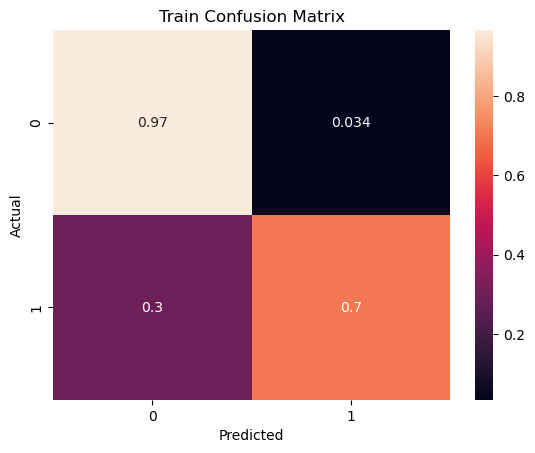

--- VALIDATION ---
AUROC: 0.9277001166060773


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


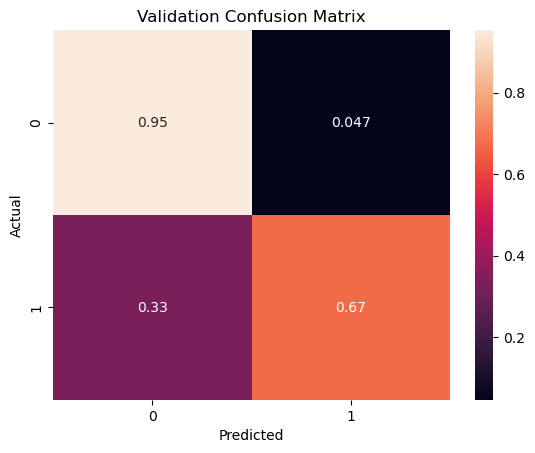

['churn_pipeline.joblib']

In [116]:
# Read train set from a file
raw_df = pd.read_csv('train.csv')

# Split data into train and validation
train_df, val_df = train_test_split(raw_df,
                                    test_size=0.2,
                                    random_state=91,
                                    stratify=raw_df.Exited)

# Select input and target subsets
input_cols = train_df.columns[1:-1]
target_col = "Exited"
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

# Select numeric and categorical columns
numeric_cols = train_inputs.select_dtypes("number").columns.to_list()
categorical_cols = train_inputs.select_dtypes("object").columns.to_list()

# Create a pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial', PolynomialFeatures(degree=4))
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])
model_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=200))  # because it reaches limit at 100
])

# Fit the pipeline
model_pipeline.fit(train_inputs, train_target)


# Create function to predict probabilities and classes + show some metrics
def predict_and_show_metrics(df_name, inputs, target):
    print(f"--- {df_name.upper()} ---")
    probs = model_pipeline.predict_proba(inputs)
    preds = model_pipeline.predict(inputs)

    fpr, tpr, thresholds = roc_curve(target, probs[:, 1])
    auc_roc = auc(fpr, tpr)

    print('AUROC:', auc_roc)

    cf_norm = confusion_matrix(target, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf_norm, annot=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{df_name} Confusion Matrix')
    plt.show()

    return {'probs': probs[:, 1], 'preds': preds}


# Make predictions and show metrics for train and val
train_results = predict_and_show_metrics('Train', train_inputs, train_target)
val_results = predict_and_show_metrics('Validation', val_inputs, val_target)

# Write model into a file
joblib.dump(model_pipeline, 'churn_pipeline.joblib')

In [117]:
# Check number of features
len(model_pipeline[:-1].get_feature_names_out())

1454

**Висновок.** Зі збільшенням степені поліномів продовжується тенденція покращення результатів: вищі показники `AUROC` і `True positive` для тренувального і валідаційного сетів. Все ще не спостерігається overfit i underfit - генералізація хороша. Загалом модель краща за попередню.

Щодо подальших експериментів: кількість параметрів уже доволі висока, подальше збільшення `degree` може призвести до оверфіту. Також трохи погіршилось визначення `True negative`. Але знову ж таки, це може бути виправлено підбіркою `threshold`.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Зчитайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [118]:
# Read train set from a file
raw_df = pd.read_csv('regression_data.csv')
raw_df

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013
...,...,...,...,...,...,...
124,1.402794,0.586857,-1.401851,0.791032,-0.909387,39.626185
125,-0.288659,-0.827231,0.322719,-1.002529,-0.018513,-50.585687
126,-1.407464,-0.213447,-0.718444,0.232050,-1.448084,13.719861
127,1.353872,1.237816,-0.114540,-0.469176,-1.713135,-23.851350


In [119]:
# Split data into train and validation
train_df, test_df = train_test_split(raw_df,
                                     test_size=0.2,
                                     random_state=19)

# Select input and target subsets
input_cols = train_df.columns[:-1]
target_col = "target"
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()
test_inputs = test_df[input_cols].copy()
test_target = test_df[target_col].copy()

In [120]:
# Create a pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial', PolynomialFeatures(degree=5))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, input_cols)
])
model_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LinearRegression())
])

In [121]:
# Fit the pipeline
model_pipeline.fit(train_inputs, train_target)

# Predict target for train and test
train_preds = model_pipeline.predict(train_inputs)
test_preds = model_pipeline.predict(test_inputs)

In [122]:
# Get metrics
train_rmse = root_mean_squared_error(train_target, train_preds)
train_r2 = r2_score(train_target, train_preds)

test_rmse = root_mean_squared_error(test_target, test_preds)
test_r2 = r2_score(test_target, test_preds)

print("Train metrics.", "RMSE:", train_rmse, "| R2 score:", train_r2)
print("Test metrics.", "RMSE:", test_rmse, "| R2 score:", test_r2)

Train metrics. RMSE: 3.926383494020559e-13 | R2 score: 1.0
Test metrics. RMSE: 24.031529188569795 | R2 score: 0.746532138584355


In [123]:
# Calculate mean and standard deviation for target
np.mean(train_target), np.std(train_target)

(np.float64(-6.261515824720881), 44.34210030398828)

**Висновок.** На тренувальному наборі модель показує неймовірно низьке `RMSE` та ідеальну оцінку `R2`. Це дуже сильний натяк на оверфіт. І хоча метрики на тестувальному наборі не такі вже й погані, вони на порядки гірші, ніж на тренувальному. На якомусь іншому тестувальному наборі модель могла би показати жахливі результати. Тому це оверфіт і модель потребує доопрацювання.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [124]:
def run_model(model_name, model):
    # Create a pipeline
    numeric_transformer = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('polynomial', PolynomialFeatures(degree=20))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, input_cols)
    ])
    model_pipeline = Pipeline(steps=[
        ('prep', preprocessor),
        ('model', model)
    ])

    # Fit the pipeline
    model_pipeline.fit(train_inputs, train_target)

    # Predict target for train and test
    train_preds = model_pipeline.predict(train_inputs)
    test_preds = model_pipeline.predict(test_inputs)

    # Get metrics
    train_rmse = root_mean_squared_error(train_target, train_preds)
    train_r2 = r2_score(train_target, train_preds)

    test_rmse = root_mean_squared_error(test_target, test_preds)
    test_r2 = r2_score(test_target, test_preds)

    print('--- MODEL', model_name, '---')
    print('Train metrics.', 'RMSE:', train_rmse, '| R2 score:', train_r2)
    print('Test metrics.', 'RMSE:', test_rmse, '| R2 score:', test_r2)
    print('\n')

In [125]:
# Run models and compare metrics
models = {
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet()
}

for key in models.keys():
    run_model(key, models[key])

--- MODEL Lasso ---
Train metrics. RMSE: 5.209237393232883 | R2 score: 0.9861988340279337
Test metrics. RMSE: 5.786457330347481 | R2 score: 0.9853044583981784


--- MODEL Ridge ---
Train metrics. RMSE: 5.753230015774452 | R2 score: 0.9831658592052114
Test metrics. RMSE: 7.113285268539311 | R2 score: 0.9777924556396861


--- MODEL ElasticNet ---
Train metrics. RMSE: 31.492329155223718 | R2 score: 0.49559771655714746
Test metrics. RMSE: 29.39915582245332 | R2 score: 0.6206589806753697




In [126]:
# Check number of non-zero coefficients
for key in models.keys():
    print(key, np.sum(models[key].coef_ != 0))

Lasso 1
Ridge 53129
ElasticNet 151


In [127]:
# Check the coefficient values
for key in models.keys():
    print(key, np.sort(models[key].coef_), '\n')

Lasso [  0.          0.         -0.        ...   0.          0.
 199.8770828] 

Ridge [-7.43972853 -5.20552499 -4.93537914 ... 27.64874499 34.12175891
 54.60543265] 

ElasticNet [-1.27240264 -1.12011666 -0.8088955  ...  7.26040434  9.68649529
 11.16627705] 



**Висновок.** Найкращі результати показала модель `Lasso`. Вона обнулила всі параметри, крім одного. Виходить тільки 1 параметр є насправді важливим у цьому датасеті. Трошки гірші результати у `Ridge`. Вона зменшила оверфіт, підігнавши коефіцієнти. Модель `ElasticNet` показала найгірші результати. Ця модель обнулила більшість параметрів і залишила тільки 151. ВОна показала доволі високі `RMSE`, а `R2 score` виявилась взагалі кращою для тестового набору, ніж до тренувального. А це сигналізує про андерфіт.

Отже модель `ElasticNet` не принесла користі порівняно зі звичайною Лінійною регресією.

Моделі `Lasso` і `Ridge` показали значне покращення результатів порівняно з Лінійною регресією, особливо в контексті генералізації.

Остаточний вибір - `Lasso`, адже ця модель показала найкращі результати, при тому максимально спростивши набір даних, залишивши тільки 1 важливий параметр.